# Clustering the Pokemon Dataset - Report Verification

This notebook is created to reproduce and visually verify the findings from the Pokemon entity clustering report. The focus is on exploratory data analysis (especially the distribution of the `base_experience` attribute), correlation analyses, and the evaluation of the K-Means model.

## 0. Import libraries



In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42



## 1. Loading and basic data checks

The report states that the dataset contains 588 rows and 13 attributes, and that there are no missing values or duplicates.
*(Note: Adjust the file path to your local environment)*



In [15]:
# Assuming the data is located in the 'train.csv' file.
# If you have separate train/test files, we will load them later. We use the full dataset here for EDA.
try:
    df = pd.read_csv('train.csv')
    print("Dataset shape:", df.shape)
    print("Number of duplicates:", df.duplicated().sum())
    print("Number of missing values per column:\n", df.isna().sum())
    display(df.head())
except FileNotFoundError:
    print("File 'train.csv' not found in the working directory. Please adjust the path.")


Dataset shape: (588, 13)
Number of duplicates: 0
Number of missing values per column:
 description        0
height             0
weight             0
base_experience    0
is_legendary       0
is_mythical        0
generation         0
hp                 0
attack             0
defense            0
special-attack     0
special-defense    0
speed              0
dtype: int64


,description,height,weight,base_experience,is_legendary,is_mythical,generation,hp,attack,defense,special-attack,special-defense,speed
0,POKeMON kome se divili od prošlosti zbog svoje...,19,1550,194,False,False,generation-i,90,110,80,100,80,95
1,Živeo je u džungli pre oko 100 miliona godina....,9,315,70,False,False,generation-iv,67,125,40,30,30,58
2,GARDEVOIR ima sposobnost čitanja budućnosti. A...,16,484,233,False,False,generation-iii,68,65,65,125,115,80
3,VIGOROT uvek svrbi i uznemiren da divlja. Jedn...,14,465,154,False,False,generation-iii,80,80,80,55,55,90
4,Koristi svoju snažnu psihičku moć da stisne mo...,5,90,67,False,False,generation-v,55,55,55,85,55,30



## 1.1 Distributions of numerical attributes and normality tests

The report claims that all nine numerical attributes reject normality (Shapiro-Wilk p \< 0.001) and that `height` and `weight` exhibit high positive skewness (\>4).



,Attribute,Shapiro p-value,Skewness
0,hp,9.139134e-18,1.540800
1,attack,4.724269e-06,0.386415
2,defense,9.453482e-14,1.007844
3,special-attack,5.388648e-09,0.543496
4,special-defense,2.217368e-09,0.622003
5,speed,1.192695e-05,0.394089
6,height,4.840730e-32,4.112148
7,weight,4.260073e-36,4.400863
8,base_experience,3.257429e-17,0.616663


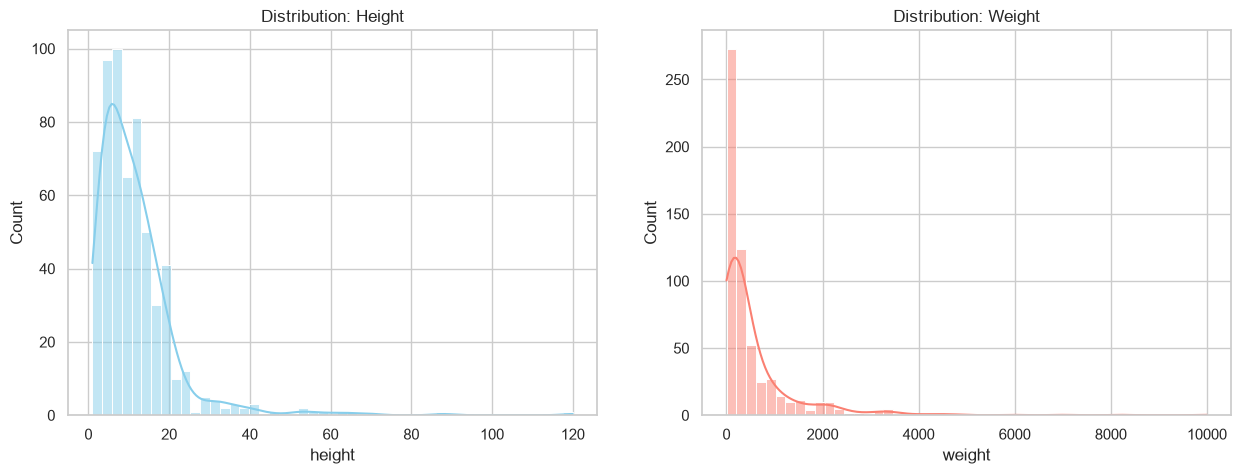

In [16]:
# Extracting numerical columns
numeric_cols = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed', 'height', 'weight', 'base_experience']

# Shapiro-Wilk test and Skewness
stats_list = []
for col in numeric_cols:
    stat, p_val = stats.shapiro(df[col].dropna())
    skewness = df[col].skew()
    stats_list.append({'Attribute': col, 'Shapiro p-value': p_val, 'Skewness': skewness})

stats_df = pd.DataFrame(stats_list)
display(stats_df)

# Visualization of highly skewed attributes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['height'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution: Height')
sns.histplot(df['weight'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution: Weight')
plt.show()



### The bimodal nature of `base_experience`

Key finding: `base_experience` develops a bimodal density structure after a logarithmic transformation, forming a natural valley around the value 107.



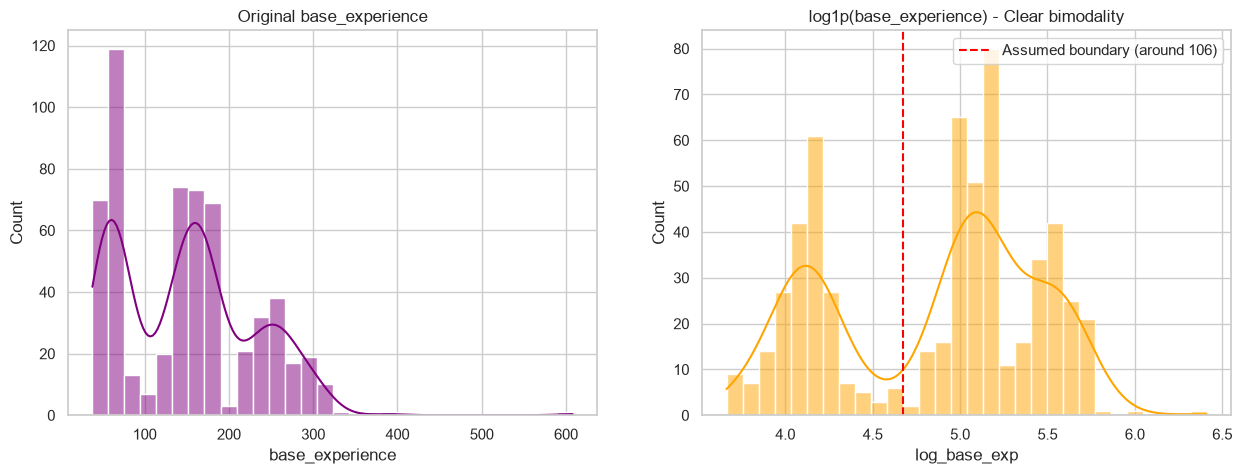

In [17]:
df['log_base_exp'] = np.log1p(df['base_experience'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original distribution
sns.histplot(df['base_experience'], kde=True, ax=axes[0], color='purple', bins=30)
axes[0].set_title('Original base_experience')

# Log-transformed distribution
sns.histplot(df['log_base_exp'], kde=True, ax=axes[1], color='orange', bins=30)
axes[1].axvline(np.log1p(106), color='red', linestyle='--', label='Assumed boundary (around 106)')
axes[1].set_title('log1p(base_experience) - Clear bimodality')
axes[1].legend()

plt.show()



## 1.2 and 1.3 Correlation structure

The report states that `base_experience` has the strongest correlations with combat statistics, while the Point-Biserial correlation with `is_legendary` is approximately 0.409.



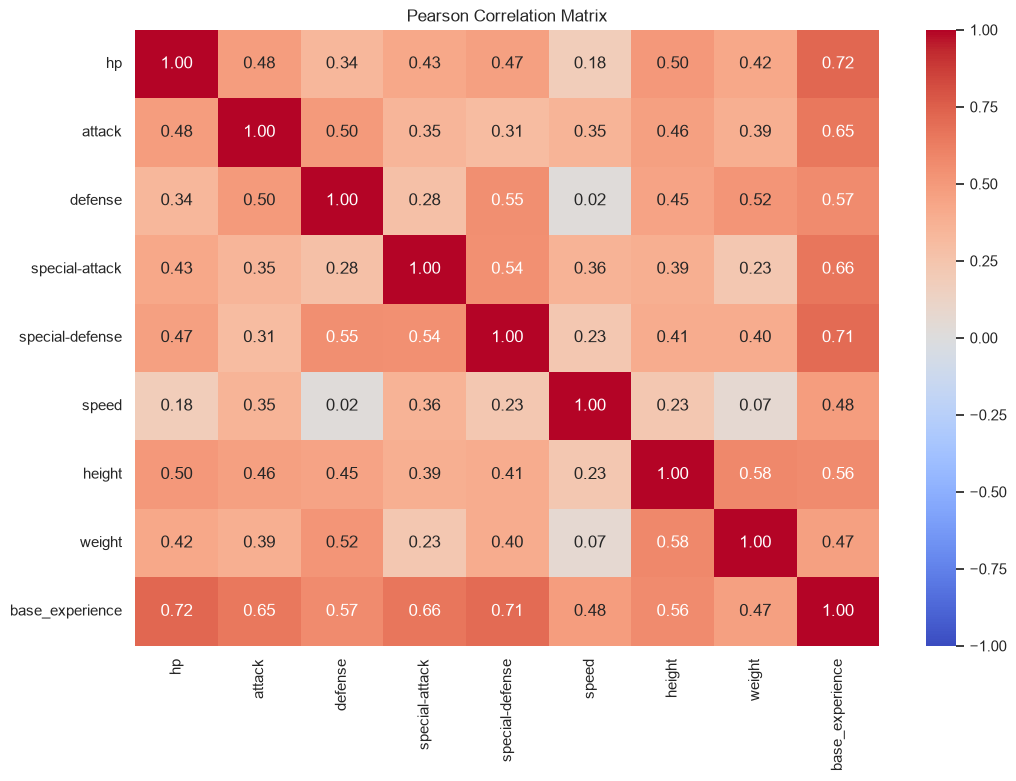

Correlation with is_legendary:


,Attribute,Point-Biserial r
8,base_experience,0.409249
7,weight,0.383325
4,special-defense,0.350125
6,height,0.302873
3,special-attack,0.295965
0,hp,0.292060
2,defense,0.256309
5,speed,0.255365
1,attack,0.253197



Average values grouped by legendary status:


,base_experience
is_legendary,
False,139.421245
True,266.071429


In [18]:
# Pearson correlation matrix
plt.figure(figsize=(12, 8))
corr_pearson = df[numeric_cols].corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.show()

# Point-biserial correlation with 'is_legendary'
pb_corrs = []
for col in numeric_cols:
    corr, p = stats.pointbiserialr(df['is_legendary'], df[col].dropna())
    pb_corrs.append({'Attribute': col, 'Point-Biserial r': corr})

pb_df = pd.DataFrame(pb_corrs).sort_values(by='Point-Biserial r', ascending=False)
print("Correlation with is_legendary:")
display(pb_df)

# Grouping by is_legendary
print("\nAverage values grouped by legendary status:")
display(df.groupby('is_legendary')[['base_experience']].mean())



## 2. Feature engineering and scaling

Simulation of selecting transformations for the `base_experience` attribute. We compare raw values, `log1p`, and `sqrt`.



In [19]:
# Creating transformations for testing (simulating the Silhouette score on the full dataset for a quick check)
# The report performed this on train/test, but here we do a quick showcase of how transformations affect separability.

transforms = {
    'Raw value': df[['base_experience']].values,
    'log1p': np.log1p(df[['base_experience']].values),
    'sqrt': np.sqrt(df[['base_experience']].values)
}

print("Comparison of transformation impacts (K-Means, k=2, on the full dataset):")
for name, data in transforms.items():
    scaled_data = StandardScaler().fit_transform(data)
    labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=50).fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"{name}: Silhouette score = {score:.4f}")


Comparison of transformation impacts (K-Means, k=2, on the full dataset):
Raw value: Silhouette score = 0.6258
log1p: Silhouette score = 0.7524
sqrt: Silhouette score = 0.7046


## 3. Clustering and Dimensionality Reduction (PCA)

Following the correlation analysis, the next step in our machine learning pipeline is to identify natural groupings among the Pokémon based on their combat statistics. Because the base combat stats (`hp`, `attack`, `defense`, `special-attack`, `special-defense`, `speed`) exist in a 6-dimensional feature space, interpreting the clustering assignments visually is highly complex.

To address this, we will utilize **Principal Component Analysis (PCA)** to reduce the feature space into two main components. Before applying PCA and our chosen clustering algorithms (**K-Means** and **DBSCAN**), it is crucial to apply standard scaling (`StandardScaler`). This ensures that attributes with naturally larger ranges do not disproportionately influence the distance metrics calculated by the algorithms.

The following cell standardizes the data, computes the cluster assignments, and projects the high-dimensional data onto a 2D plane for visual evaluation.

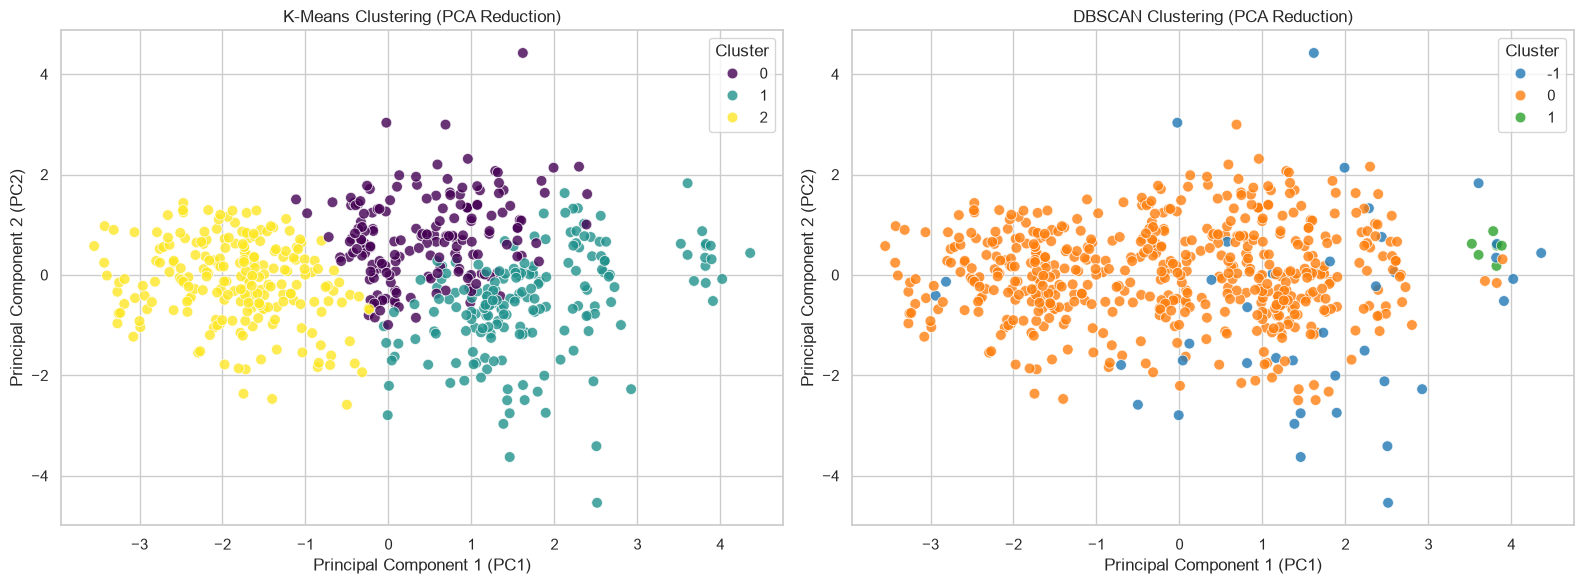

Total explained variance with 2 components: 64.94%


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Adjust the list of numerical columns to match the ones actually used in your code
numeric_features = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed'] 
X = df[numeric_features].dropna()

# 1. Data standardization (crucial for K-Means, DBSCAN, and PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Model training (if you already have labels in the notebook, you can skip this part
# and just pass them into the pca_df below)
kmeans = KMeans(n_clusters=3, random_state=42) # adjust the number of clusters for your analysis
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=5) # adjust eps and min_samples
dbscan_labels = dbscan.fit_predict(X_scaled)

# 3. PCA dimensionality reduction to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a helper DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['KMeans_Cluster'] = kmeans_labels
pca_df['DBSCAN_Cluster'] = dbscan_labels

# 4. Result visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means plot
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=pca_df, 
                palette='viridis', ax=axes[0], s=60, alpha=0.8)
axes[0].set_title('K-Means Clustering (PCA Reduction)')
axes[0].set_xlabel('Principal Component 1 (PC1)')
axes[0].set_ylabel('Principal Component 2 (PC2)')
axes[0].legend(title='Cluster')

# DBSCAN plot (cluster -1 represents noise/outliers)
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=pca_df, 
                palette='tab10', ax=axes[1], s=60, alpha=0.8)
axes[1].set_title('DBSCAN Clustering (PCA Reduction)')
axes[1].set_xlabel('Principal Component 1 (PC1)')
axes[1].set_ylabel('Principal Component 2 (PC2)')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

# Display explained variance (how much information from the original data is retained by these 2 components)
print(f"Total explained variance with 2 components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")


## 4. Data splitting and training the final model (K-Means)

Applying the code from your final script: stratified splitting and calculating the required metric on the test set.



In [ ]:
# Data preparation
X_full = df[['base_experience', 'is_legendary']].copy()
X_full['log_base_exp'] = np.log1p(X_full['base_experience'])

# Stratified split (80/20)
train_df, test_df = train_test_split(
    X_full, 
    test_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=X_full['is_legendary']
)

# Scaler initialization and scaling (fit on train only)
ss = StandardScaler()
X_train = ss.fit_transform(train_df[['log_base_exp']].values)
X_test = ss.transform(test_df[['log_base_exp']].values)

# Training the K-Means model (from the production script)
km = KMeans(
    n_clusters=2,
    algorithm="lloyd",
    init="k-means++",
    n_init=300,
    max_iter=2000,
    tol=1e-6,
    random_state=RANDOM_STATE,
)

km.fit(X_train)
labels_train = km.predict(X_train)
labels_test = km.predict(X_test)

test_silhouette = silhouette_score(X_test, labels_test)
print(f"K-Means Test Silhouette score (goal > 0.70): {test_silhouette:.4f}")


K-Means Test Silhouette score (goal > 0.70): 0.7434



## 5. Additional metrics and cluster visualization

Testing the other models mentioned in the report (GMM) and visualizing the clusters in the 1D space of the original `base_experience`.



GMM Test Silhouette score: 0.7434

Cluster 0 Center (original space): 187.1
Cluster 1 Center (original space): 60.2


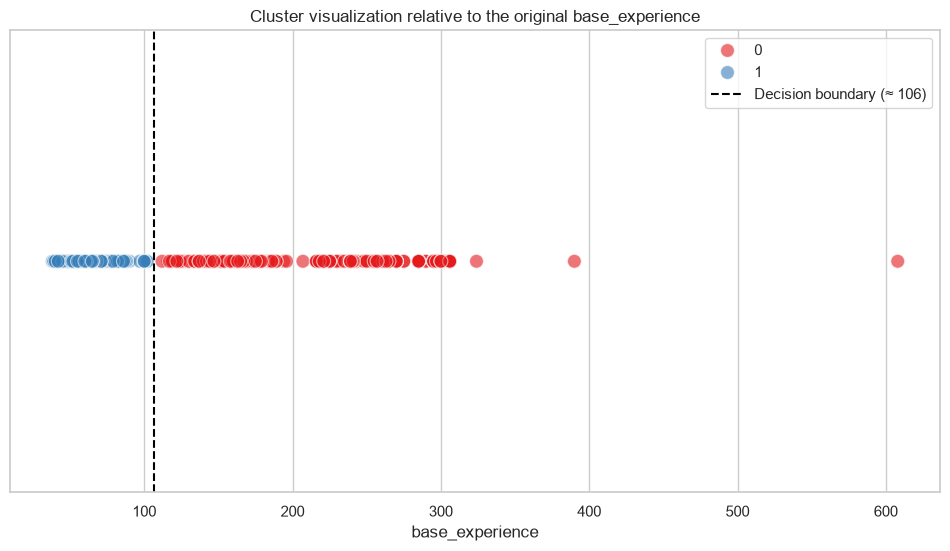

Cluster profiling:


,Avg_base_exp,Min_base_exp,Max_base_exp,Entity_Count,Legendary_Count
Cluster,,,,,
0,196.155263,112,608,380,40
1,61.346154,38,102,208,2


In [ ]:
# GMM with parameters from the report
gmm = GaussianMixture(n_components=2, covariance_type='tied', n_init=50, tol=1e-6, random_state=RANDOM_STATE)
gmm.fit(X_train)
gmm_test_labels = gmm.predict(X_test)
print(f"GMM Test Silhouette score: {silhouette_score(X_test, gmm_test_labels):.4f}")

# Inverse transformation of cluster centers (from StandardScaler space back to log space, then to original space)
centers_scaled = km.cluster_centers_
centers_log = ss.inverse_transform(centers_scaled)
centers_original = np.expm1(centers_log)

print(f"\nCluster 0 Center (original space): {centers_original[0][0]:.1f}")
print(f"Cluster 1 Center (original space): {centers_original[1][0]:.1f}")

# Visualization on the entire dataset
X_all = ss.transform(X_full[['log_base_exp']].values)
all_labels = km.predict(X_all)
X_full['Cluster'] = all_labels

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=X_full, 
    x='base_experience', 
    y=np.zeros(len(X_full)), # Keeping them on a 1D line
    hue='Cluster', 
    palette='Set1',
    alpha=0.6,
    s=100
)

# Drawing the boundary (midpoint between centers)
# To find the decision boundary in 1D K-means, we look for the point equidistant to both centers
boundary_scaled = np.mean(centers_scaled)
boundary_log = ss.inverse_transform([[boundary_scaled]])
boundary_original = np.expm1(boundary_log)[0][0]

plt.axvline(boundary_original, color='black', linestyle='--', label=f'Decision boundary (≈ {boundary_original:.0f})')
plt.title('Cluster visualization relative to the original base_experience')
plt.yticks([]) # Hiding the Y axis since it's irrelevant for 1D data
plt.legend()
plt.show()

# Cluster profiling
print("Cluster profiling:")
display(X_full.groupby('Cluster').agg(
    Avg_base_exp=('base_experience', 'mean'),
    Min_base_exp=('base_experience', 'min'),
    Max_base_exp=('base_experience', 'max'),
    Entity_Count=('base_experience', 'count'),
    Legendary_Count=('is_legendary', 'sum')
))
